# Exploring Global Weather Forecasts with Zarr on Google Cloud Storage and WeatherNext 2

**Welcome!** This notebook introduces a weather forecast dataset available in Zarr format on Google Cloud Storage, generated by Google DeepMind and Google Research's WeatherNext 2 model. Through a series of sample queries, we'll demonstrate how to access, analyze, and visualize this data to gain insights into global weather patterns, trends, and potential impacts.

**Dataset Overview**

This dataset offers weather forecasts produced by WeatherNext 2, a state-of-the-art machine learning model developed by Google DeepMind and Google Research. It provides predictions for various weather variables, including temperature, precipitation, wind speed, and more, at a global scale and with a high degree of accuracy. Each forecast consists of 64 ensemble members, representing 64 different possible outcomes.

**Notebook Purpose**

This notebook aims to:

* Familiarize users with the structure and content of the WeatherNext 2 weather forecast dataset in Zarr.
* Demonstrate how to query and analyze this data using the Xarray library's powerful tools and functions.
* Showcase the potential applications of this data for various weather-related tasks, such as forecasting, climate analysis, and risk assessment.

**Copyright Information**

Copyright 2025 Google LLC.

All materials are licensed under the [Creative Commons Attribution 4.0 International License (CC-BY)](https://creativecommons.org/licenses/by/4.0/legalcode).

**Additional Documentation**

[Xarray Library Documentation](https://docs.xarray.dev)

## Import Python Libraries & Some Other Setup

In [3]:
!uv add rioxarray zarr gcsfs google-cloud-storage


Resolved 176 packages in 1ms
Audited 156 packages in 0.65ms


In [15]:
# from collections.abc import Mapping

import gcsfs
# from google.colab import auth
import folium
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import rioxarray
import shapely
import seaborn as sns
import numpy as np
import xarray as xr
import zarr

import warnings
# Suppress the FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning)

## Set Google Cloud Project ID

In [5]:
project_id = '<project-name>' #@param{type:"string"}

# Weather Forecast Dataset Schema

This describes the schema for a weather forecast dataset.

## Dimensions

<div align="left">

| Name | Type | Description |
| --- | --- | --- |
| `lat` | float32 | The latitude of the forecast. |
| `level`  | int64 | The pressure level, e.g., 50, 100... 1000 hPa. For surface-level variables, this is 0. |
| `lon` | float32 | The longitude of the forecast. |
| `sample` | int64 | The ID of the member in the ensemble. |
| `time` | timedelta64[ns] | The forecast lead time. Represents the number of hours from the init time (as indicated in the zarr filename).

</div>

## Variables

<div align="left">

| Name | Units | Description |
|---|---|---|
| `total_precipitation_6hr` | m | Total precipitation over a 6-hour period |
| `10m_u_component_of_wind` | m/s | The u-component of wind at 10 meters above the surface |
| `10m_v_component_of_wind` | m/s | The v-component of wind at 10 meters above the surface |
| `100m_u_component_of_wind` | m/s | The u-component of wind at 100 meters above the surface |
| `100m_v_component_of_wind` | m/s | The v-component of wind at 100 meters above the surface |
| `2m_temperature` | K | Temperature at 2 meters above the surface |
| `mean_sea_level_pressure` | Pa | Mean sea level pressure |

There are also values for the following variables at various pressure levels (50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000 hPa). They are stored along the `level` dimension:

| Name | Units | Description |
|---|---|---|
| `geopotential` | m^2/s^2 | Geopotential |
| `specific_humidity` | kg/kg | Specific humidity |
| `temperature` | K | Temperature |
| `u_component_of_wind` | m/s | The u-component of wind |
| `v_component_of_wind` | m/s | The v-component of wind |
| `vertical_velocity` | Pa/s | Vertical velocity |

</div>

# Example Queries

First, let's open the zarr dataset in GCS for a specific init timestamp (2025-10-03 00:00 UTC).

In [6]:
import gcsfs
import zarr
import xarray as xr

# This will automatically use the credentials from the file saved above
fs = gcsfs.GCSFileSystem()

zstore = zarr.storage.FsspecStore(
    fs,
    path="weathernext/weathernext_2_0_0/zarr/2025_to_present/20251003_00hr_01_preds/predictions.zarr"
)

ds = xr.open_zarr(zstore)
print(ds)

/Users/ohouck/vc/ai_weather_ag/.venv/lib/python3.11/site-packages/google/auth/_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
/var/folders/f1/ns9p3knx5tn5wf7rkr_cd9dw0000gn/T/ipykernel_95283/2837024346.py:8: ZarrUserWarning: fs (<gcsfs.core.GCSFileSystem object at 0x115e5ecd0>) was not created with `asynchronous=True`, this may lead to surprising behavior
  zstore = zarr.storage.FsspecStore(
/Users/ohouck/vc/ai_weather_ag/.venv/lib/python3.11/site-packages/zarr/storage/_fsspec.py:259: ZarrUserWarning: fs (<gcsfs.core.GCSFileSystem object at 0x115e5ecd0>) was not created with `asynchronous=True`, this may lead to surprising behavior
  return type(self)(


<xarray.Dataset> Size: 1TB
Dimensions:                   (sample: 64, time: 60, lat: 721, lon: 1440,
                               level: 13)
Coordinates:
  * sample                    (sample) int64 512B 0 1 2 3 4 5 ... 59 60 61 62 63
  * time                      (time) timedelta64[ns] 480B 0 days 06:00:00 ......
  * lat                       (lat) float32 3kB -90.0 -89.75 ... 89.75 90.0
  * lon                       (lon) float32 6kB 0.0 0.25 0.5 ... 359.5 359.8
  * level                     (level) int32 52B 50 100 150 200 ... 850 925 1000
    datetime                  (time) datetime64[ns] 480B dask.array<chunksize=(60,), meta=np.ndarray>
    init_time                 datetime64[ns] 8B ...
Data variables: (12/14)
    100m_u_component_of_wind  (sample, time, lat, lon) float32 16GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    100m_v_component_of_wind  (sample, time, lat, lon) float32 16GB dask.array<chunksize=(1, 1, 721, 1440), meta=np.ndarray>
    10m_u_component_o

## Exploring Temperature Forecasts for New York City - 5 Day

This query retrieves the 2-meter temperature forecasts for New York, NY, across all the ensemble members for the given init time, demonstrating how to access and analyze the core weather data in the dataset.

In [8]:
import shapely

# Note: longitudes in this dataset use 0-360 range.
nyc_polygon = shapely.geometry.Polygon([(289.34, 40.64), (286.15, 40.64), (286.15, 40.89), (289.34, 40.89), (289.34, 40.64)])

nyc_ds = ds.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
nyc_ds.rio.write_crs("EPSG:4326", inplace=True)
nyc_ds = nyc_ds.rio.clip([nyc_polygon], crs="EPSG:4326")

# Show schema for clipped dataset
nyc_ds

<xarray.Dataset> Size: 17MB
Dimensions:                   (time: 60, lat: 1, lon: 13, sample: 64, level: 13)
Coordinates:
  * time                      (time) timedelta64[ns] 480B 0 days 06:00:00 ......
  * lat                       (lat) float32 4B 40.75
  * lon                       (lon) float32 52B 286.2 286.5 ... 289.0 289.2
  * sample                    (sample) int64 512B 0 1 2 3 4 5 ... 59 60 61 62 63
  * level                     (level) int32 52B 50 100 150 200 ... 850 925 1000
    datetime                  (time) datetime64[ns] 480B dask.array<chunksize=(60,), meta=np.ndarray>
    init_time                 datetime64[ns] 8B ...
    spatial_ref               int64 8B 0
Data variables: (12/14)
    100m_u_component_of_wind  (sample, time, lat, lon) float32 200kB dask.array<chunksize=(1, 1, 1, 13), meta=np.ndarray>
    100m_v_component_of_wind  (sample, time, lat, lon) float32 200kB dask.array<chunksize=(1, 1, 1, 13), meta=np.ndarray>
    10m_u_component_of_wind   (sample, time, lat, lon) float32 200kB dask.array<chunksize=(1, 1, 1, 13), meta=np.ndarray>
    10m_v_component_of_wind   (sample, time, lat, lon) float32 200kB dask.array<chunksize=(1, 1, 1, 13), meta=np.ndarray>
    2m_temperature            (sample, time, lat, lon) float32 200kB dask.array<chunksize=(1, 1, 1, 13), meta=np.ndarray>
    geopotential              (sample, time, level, lat, lon) float32 3MB dask.array<chunksize=(1, 1, 1, 1, 13), meta=np.ndarray>
    ...                        ...
    specific_humidity         (sample, time, level, lat, lon) float32 3MB dask.array<chunksize=(1, 1, 1, 1, 13), meta=np.ndarray>
    temperature               (sample, time, level, lat, lon) float32 3MB dask.array<chunksize=(1, 1, 1, 1, 13), meta=np.ndarray>
    total_precipitation_6hr   (sample, time, lat, lon) float32 200kB dask.array<chunksize=(1, 1, 1, 13), meta=np.ndarray>
    u_component_of_wind       (sample, time, level, lat, lon) float32 3MB dask.array<chunksize=(1, 1, 1, 1, 13), meta=np.ndarray>
    v_component_of_wind       (sample, time, level, lat, lon) float32 3MB dask.array<chunksize=(1, 1, 1, 1, 13), meta=np.ndarray>
    vertical_velocity         (sample, time, level, lat, lon) float32 3MB dask.array<chunksize=(1, 1, 1, 1, 13), meta=np.ndarray>

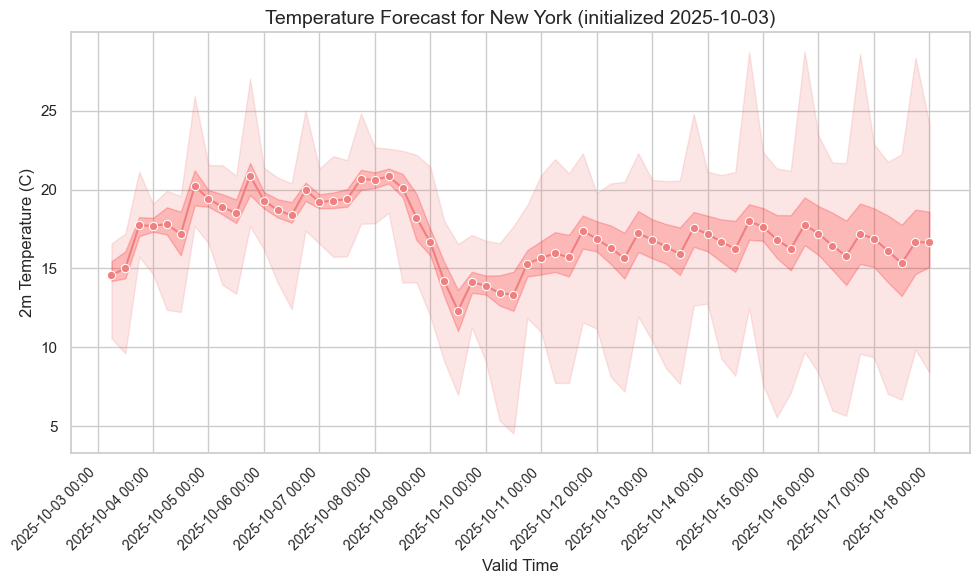

In [16]:
# Generating the plot can take up to 5 minutes.
import numpy as np
# Stack the 2m_temperature values so we can get a 1D array for plotting purposes.
nyc_temps = nyc_ds['2m_temperature'].stack(stacked_2m_temperature=('lat', 'lon', 'sample', 'time'))

# Programatically determine the init_time and get it in string format to display
# as the plot title. There should only be a single init_time in this dataset.
forecast_date = np.datetime_as_string(nyc_temps['init_time'].values, unit='D')

# Set the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Plot the data
# This will display a graph with a line representing the average temp, and
# error bars representing the min and max for each forecast time.
# The average temp is the average across all ensembles AND all points inside
# NYC.
# The average is implicitly calculated by the plotting library.

plt.figure(figsize=(10, 6))

# Avg with min and max band
def min_max_err(x):
  return (x.min(), x.max())
sns.lineplot(
    x=mdates.date2num(nyc_temps['datetime']),
    y=nyc_temps - 273.15,
    errorbar=min_max_err,
    marker='o',
    linestyle='-',
    color='lightcoral'
)

# 50th percentile band
sns.lineplot(
    x=mdates.date2num(nyc_temps['datetime'].values),
    y=nyc_temps - 273.15,
    errorbar=('pi', 50),
    marker='',
    linestyle='',
    color='red'
)

plt.xlabel('Valid Time', fontsize=12)
plt.ylabel('2m Temperature (C)', fontsize=12)
plt.title(f'Temperature Forecast for New York (initialized {forecast_date})', fontsize=14)

# Format the x-axis ticks
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))  # Show date and time
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))  # Show ticks for each day
plt.xticks(rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

## Deterministic forecasts

The forecasts produced by WeatherNext 2 consist of ensembles. To get a single deterministic forecast, you can average the values across all the ensembles, as in the following example:

### World - 10/03/2025 06:00 Hours
This query gets the values for all variables averaged over all ensemble members in a single forecast (specifically, with an init time of 2025-10-03 00:00 and valid time of 2025-10-03 06:00).

In contrast to the previous example, the average is calculated in the xarray query, and not by the plotting library.

In [ ]:
world_avgs = ds.sel(time='6h').mean(dim='sample')

# Show dataset schema. Note how the "sample" dimension has been dropped after
# calling `mean` on that dimension.
world_avgs

<xarray.Dataset> Size: 357MB
Dimensions:                   (lat: 721, lon: 1440, level: 13)
Coordinates:
  * lat                       (lat) float32 3kB -90.0 -89.75 ... 89.75 90.0
  * lon                       (lon) float32 6kB 0.0 0.25 0.5 ... 359.5 359.8
  * level                     (level) int32 52B 50 100 150 200 ... 850 925 1000
    datetime                  datetime64[ns] 8B dask.array<chunksize=(), meta=np.ndarray>
    init_time                 datetime64[ns] 8B ...
    time                      timedelta64[ns] 8B 06:00:00
Data variables: (12/14)
    100m_u_component_of_wind  (lat, lon) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    100m_v_component_of_wind  (lat, lon) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    10m_u_component_of_wind   (lat, lon) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    10m_v_component_of_wind   (lat, lon) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    2m_temperature            (lat, lon) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    geopotential              (level, lat, lon) float32 54MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    ...                        ...
    specific_humidity         (level, lat, lon) float32 54MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    temperature               (level, lat, lon) float32 54MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    total_precipitation_6hr   (lat, lon) float32 4MB dask.array<chunksize=(721, 1440), meta=np.ndarray>
    u_component_of_wind       (level, lat, lon) float32 54MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    v_component_of_wind       (level, lat, lon) float32 54MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    vertical_velocity         (level, lat, lon) float32 54MB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>


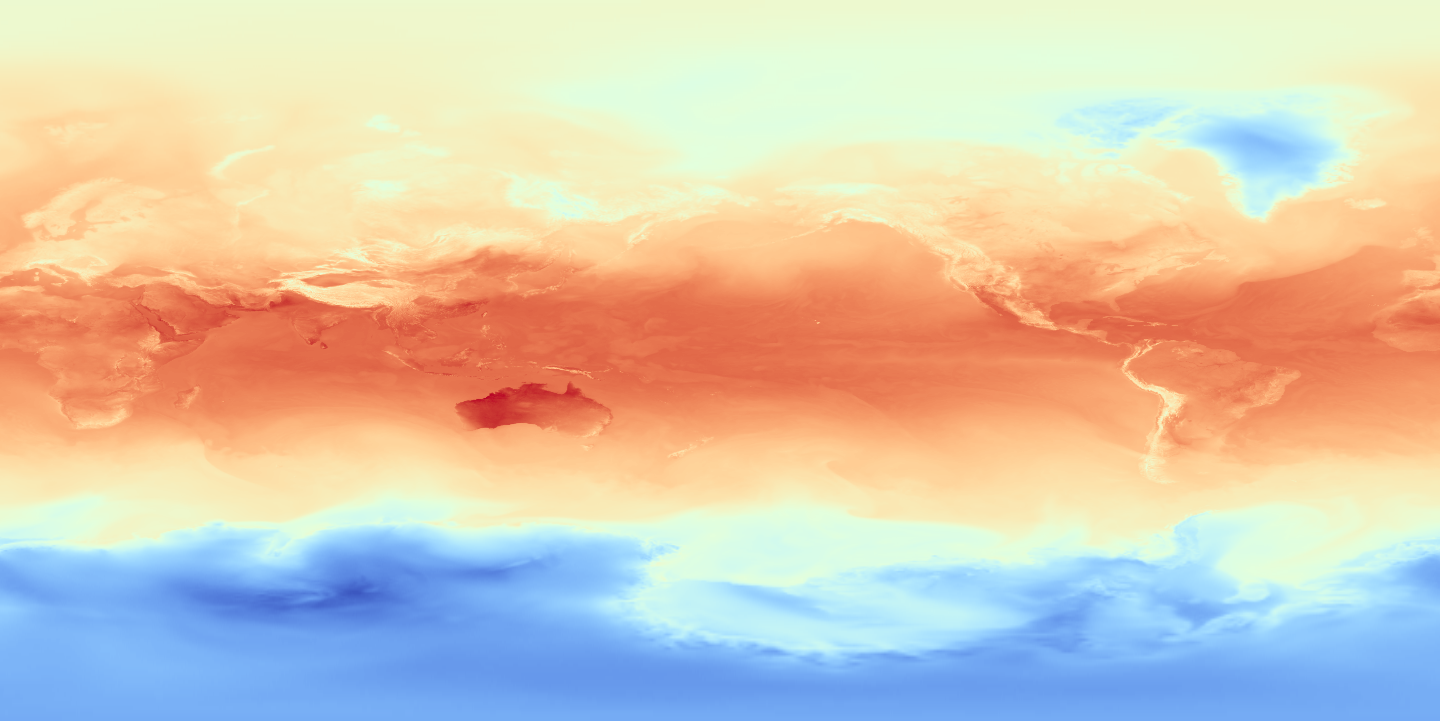

In [ ]:
# Map display options
variable = "mean_sea_level_pressure"  # @param ["2m_temperature", "10m_u_component_of_wind", "10m_v_component_of_wind", "100m_u_component_of_wind", "100m_v_component_of_wind", "mean_sea_level_pressure", "sea_surface_temperature", "total_precipitation_6hr", "geopotential", "specific_humidity", "temperature", "u_component_of_wind", "v_component_of_wind", "vertical_velocity"]
# If surface-level variable, leave as N/A.
level = "N/A"  # @param ["N/A", 50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000]
palette = "coolwarm"   # @param ["coolwarm", "Spectral_r", "BuPu"]
pixelated = False  # @param {type:"boolean"}

var_avg = world_avgs[variable]
if level != "N/A":
  var_avg = var_avg.sel(level=int(level))

# Convert points to an image

# First, get the lat, lon, and variable avg values as 1d arrays.
var_avg = var_avg.stack(lat_lon=('lat', 'lon'))
x = var_avg['lon'].values
y = var_avg['lat'].values
z = var_avg.values

ny = len(np.unique(y))
nx = len(np.unique(x))

# Bin the data onto a regular grid
zi, xi, yi = np.histogram2d(x, y, bins=(nx, ny), weights=z)
counts, _, _ = np.histogram2d(x, y, bins=(nx, ny))

zi = zi / counts
zi = np.ma.masked_invalid(zi)

# Generate colors for the image
cm = matplotlib.colormaps[palette]
normed_data = (zi - zi.min()) / (zi.max() - zi.min())
# Rotate 90 deg counterclockwise so the image will be oriented correctly
# (Folium uses lat, lon instead of lon, lat).
z = cm(np.rot90(normed_data))

# Create a base map
m = folium.Map(location=[30, 180], zoom_start=2)

# Add temperature image
folium.raster_layers.ImageOverlay(
    image=z,
    bounds=[[float(yi.min()), float(xi.min())], [float(yi.max()), float(xi.max())]],
    mercator_project=True,
    pixelated=pixelated,
    opacity=0.5,
).add_to(m)

# Display the map
m